In [28]:
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from joblib import Parallel, delayed
from neoform.simulate import simulate_game_no_mull, simulate_starting_hand
from neoform.utils import parse_decklist

In [29]:
def test_hand(starting_hand, deck_list, on_the_play, n_sims=10000, n_jobs=1):
    # run simulations in parallel
    results = Parallel(n_jobs=n_jobs)(
        delayed(simulate_starting_hand)(starting_hand, deck_list, on_the_play = on_the_play) for _ in tqdm(range(n_sims))
    )

    # extract the win turn (or None) from each result
    win = [res[0] if res is not None else None for res in results]

    win = np.array(win, dtype=float)
    average_turn_win = np.nanmean(win)
    median_turn_win = np.nanmedian(win)

    print(f'This hand wins on average on turn : {average_turn_win}, median : {median_turn_win}')

    # clean NaNs (games that didn't win)
    wins_clean = win[~np.isnan(win)]

    plt.figure(figsize=(10, 4))
    ax = sns.boxplot(x=wins_clean, color="skyblue", width=0.4)

    ax.set_xlabel("Turn to win")
    ax.set_title(f"Distribution of Winning Turn (n={len(wins_clean)})")

    # annotate mean and median
    ax.axvline(average_turn_win, color="red", linestyle="--", linewidth=2, label=f"Mean: {average_turn_win:.2f}")
    # ax.axvline(median_turn_win, color="green", linestyle="-.", linewidth=2, label=f"Median: {median_turn_win:.0f}")

    ax.legend()
    plt.tight_layout()
    plt.show()

    count_turn2 = int(np.sum(win == 2))
    pct_of_all = count_turn2 / win.size * 100
    print(f"Wins on turn 2: {count_turn2}/{win.size} -> {pct_of_all:.2f}% of all games")

    count_turn3 = int(np.sum(win <= 3))
    pct_of_all_3 = count_turn3 / win.size * 100
    
    print(f"Wins on or before turn 3: {count_turn3}/{win.size} -> {pct_of_all_3:.2f}% of all games")
    print(f"Standard deviation of winning turn: {np.std(wins_clean):.4f}")

100%|██████████| 50000/50000 [00:17<00:00, 2865.42it/s]


This hand wins on average on turn : 3.1455146000932137, median : 2.0


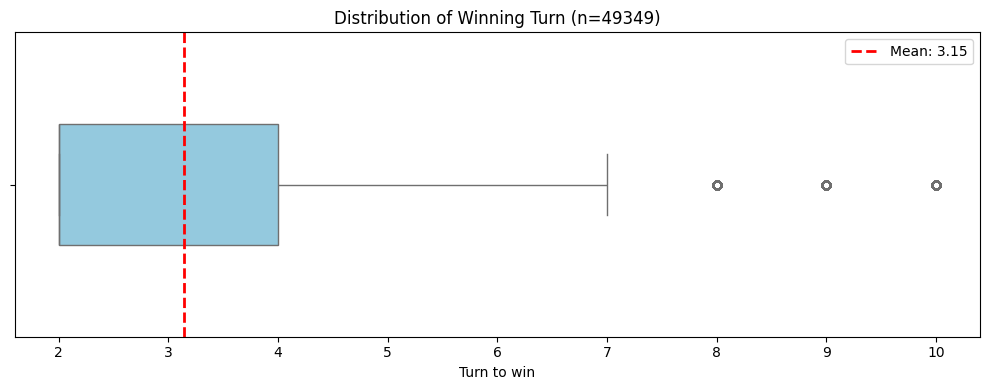

Wins on turn 2: 27651/50000 -> 55.30% of all games
Wins on or before turn 3: 35455/50000 -> 70.91% of all games
Standard deviation of winning turn: 1.7505


In [30]:
deck_list_str = """
4 Allosaurus Rider
1 Atraxa, Grand Unifier
2 Breeding Pool
4 Consign to Memory
1 Disciple of Freyalise
4 Eldritch Evolution
1 Flooded Strand
1 Generous Ent
2 Ghalta, Stampede Tyrant
1 Griselbrand
2 Hedge Maze
1 Hooting Mandrills
4 Misty Rainforest
4 Neoform
2 Nourishing Shoal
4 Pact of Negation
4 Planar Genesis
4 Preordain
2 Scalding Tarn
1 Snow-Covered Forest
2 Snow-Covered Island
2 Summoner's Pact
4 Veil of Summer
1 Wooded Foothills
1 Xenagos, God of Revels
"""

starting_hand_str = """
1 Eldritch Evolution
1 Planar Genesis
1 Neoform
1 Allosaurus Rider
1 Snow-Covered Forest
1 Consign to Memory
"""

on_the_play = False

deck_list = parse_decklist(deck_list_str)
starting_hand = parse_decklist(starting_hand_str)

n_sims = 50000
n_jobs = 1  # set to desired number of parallel workers, -1 uses all cores

test_hand(starting_hand, deck_list, on_the_play, n_sims=n_sims, n_jobs=n_jobs)